Step 1 : Imports and conventions

In [99]:
import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt

import qiskit
from qiskit import QuantumCircuit
from qiskit import transpile
from qiskit.quantum_info import Operator, SuperOp, PTM, Kraus, Statevector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

print(f"qiskit {qiskit.__version__}")

#SEED = 1234
rng = np.random.default_rng()

#Matplotlib settings
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

#Pauli Base (1 qubit)
I = np.array([[1, 0], [0, 1]], dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

PAULIS = [I, X, Y, Z]
PAULI_LABELS = ['I', 'X', 'Y', 'Z']

#Sanity checks
# a) Hermitian and P^2=I
for P in PAULIS:
    assert np.allclose(P.conj().T, P)
    assert np.allclose(P @ P, I)

# b) XY = iZ, YZ = iX, ZX = iY (cycle)
assert np.allclose(X @ Y, 1j * Z)
assert np.allclose(Y @ Z, 1j * X)
assert np.allclose(Z @ X, 1j * Y)

# c) Hilbert-Schmidt orthogonality : Tr[P_mu, P_nu] = 2 delta_{mu, nu}
hs = np.array([[np.trace(PAULIS[mu] @ PAULIS[nu]).real
                for nu in range(4)] for mu in range(4)])
assert np.allclose(hs, 2 * np.eye(4))

print("All sanity checks passed!")

qiskit 2.4.1
All sanity checks passed!


STEP 2 : PTM base toolbox

In [100]:
# ============================================================
# Cellule 2 — Boîte à outils PTM (hand-coded)
# ============================================================

def ptm_from_kraus(kraus_list):
    """
    PTM d'un canal donné par ses Kraus {K_i} :
        [N]_{mu,nu} = (1/2) sum_i Tr[P_mu K_i P_nu K_i^dagger]
    Retourne une matrice 4x4 réelle.
    """
    R = np.zeros((4, 4), dtype=float)
    for mu in range(4):
        for nu in range(4):
            acc = 0.0 + 0.0j
            for K in kraus_list:
                acc += np.trace(PAULIS[mu] @ K @ PAULIS[nu] @ K.conj().T)
            # On vérifie que la partie imaginaire est numériquement nulle
            assert abs(acc.imag) < 1e-10, f"PTM[{mu},{nu}] non réelle: {acc.imag}"
            R[mu, nu] = 0.5 * acc.real
    return R


def ptm_from_unitary(U):
    """Cas particulier : un seul Kraus K_0 = U."""
    return ptm_from_kraus([U])


def compose(R2, R1):
    """PTM de N2 ∘ N1. Sert juste à expliciter l'intention."""
    return R2 @ R1

In [101]:
#Tests
# --- Test 1 : identité ---
assert np.allclose(ptm_from_unitary(I), np.eye(4))

# --- Test 2 : Hadamard ---
# Action sur Paulis : I -> I, X -> Z, Y -> -Y, Z -> X
H = (1/np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)
R_H = ptm_from_unitary(H)
R_H_expected = np.array([
    [1, 0,  0, 0],   # ligne I
    [0, 0,  0, 1],   # ligne X : seul Z (col nu=Z=3) y arrive
    [0, 0, -1, 0],   # ligne Y : Y -> -Y
    [0, 1,  0, 0],   # ligne Z : seul X (col nu=X=1) y arrive
], dtype=float)
assert np.allclose(R_H, R_H_expected), R_H

# --- Test 3 : R_z(theta) ---
# Action : I, Z fixés ; (X, Y) tourne d'angle theta dans le plan XY
theta = 0.7
Rz = np.array([[np.exp(-1j*theta/2), 0],
               [0,                    np.exp(1j*theta/2)]], dtype=complex)
R_Rz = ptm_from_unitary(Rz)
c, s = np.cos(theta), np.sin(theta)
R_Rz_expected = np.array([
    [1, 0,  0, 0],
    [0, c, -s, 0],
    [0, s,  c, 0],
    [0, 0,  0, 1],
], dtype=float)
assert np.allclose(R_Rz, R_Rz_expected), R_Rz

# --- Test 4 : composition ---
# H @ H = I  donc  PTM(H) @ PTM(H) = identité
assert np.allclose(compose(R_H, R_H), np.eye(4))

# --- Test 5 : orthogonalité d'une PTM unitaire ---
assert np.allclose(R_H.T @ R_H, np.eye(4))
assert np.allclose(R_Rz.T @ R_Rz, np.eye(4))

# --- Test 6 : préservation de la trace ---
for R in [R_H, R_Rz]:
    assert np.allclose(R[0, :], [1, 0, 0, 0])

# --- Garde-fou Qiskit ---
qc_H = QuantumCircuit(1); qc_H.h(0)
assert np.allclose(R_H, PTM(SuperOp(qc_H)).data)

qc_Rz = QuantumCircuit(1); qc_Rz.rz(theta, 0)
assert np.allclose(R_Rz, PTM(SuperOp(qc_Rz)).data)

print("Boîte à outils PTM OK.")

Boîte à outils PTM OK.


STEP 3 : Depolarizing canal

In [102]:
# ============================================================
# Cellule 3 — Canal dépolarisant
# ============================================================

def depolarizing_kraus(eps):
    """
    Kraus du dépolarisant 1-qubit:
        D_eps(rho) = (1-eps) rho + eps I/2
                   = (1-3eps/4) rho + (eps/4)(XrX + YrY + ZrZ)
    """
    assert 0 <= eps <= 4/3, f"eps={eps} hors de [0, 4/3]"
    K0 = np.sqrt(1 - 3*eps/4) * I
    K1 = np.sqrt(eps/4)       * X
    K2 = np.sqrt(eps/4)       * Y
    K3 = np.sqrt(eps/4)       * Z
    return [K0, K1, K2, K3]


def depolarizing_ptm(eps):
    """PTM analytique : diag(1, 1-eps, 1-eps, 1-eps)."""
    return np.diag([1.0, 1.0 - eps, 1.0 - eps, 1.0 - eps])


def depolarizing_inverse_ptm(eps):
    """
    PTM de l'inverse formel (NON physique). 
    On l'isole ici car c'est l'objet cible du LP en cellule 5.
    """
    inv = 1.0 / (1.0 - eps)
    return np.diag([1.0, inv, inv, inv])

In [103]:
# --- Test 1 : complétion des Kraus ---
eps_test = 0.05
ks = depolarizing_kraus(eps_test)
completion = sum(K.conj().T @ K for K in ks)
assert np.allclose(completion, I), completion

# --- Test 2 : PTM calculée vs PTM analytique ---
R_D = ptm_from_kraus(ks)
assert np.allclose(R_D, depolarizing_ptm(eps_test))

# --- Test 3 : scan sur plusieurs valeurs d'eps ---
for e in [0.0, 1e-4, 0.01, 0.1, 0.5, 1.0, 4/3 - 1e-9]:
    Ks = depolarizing_kraus(e)
    assert np.allclose(sum(K.conj().T @ K for K in Ks), I)
    assert np.allclose(ptm_from_kraus(Ks), depolarizing_ptm(e))

# --- Test 4 : cas limite eps=0 (canal identité) ---
assert np.allclose(ptm_from_kraus(depolarizing_kraus(0.0)), np.eye(4))

# --- Test 5 : cas limite eps=1 (canal "totalement bruité") ---
# D_1(rho) = I/2 pour tout rho ; en PTM : ne reste que la projection sur I
R_D_max = ptm_from_kraus(depolarizing_kraus(1.0))
assert np.allclose(R_D_max, np.diag([1, 0, 0, 0]))

# --- Test 6 : cohérence de l'inverse ---
R_inv = depolarizing_inverse_ptm(eps_test)
assert np.allclose(R_D @ R_inv, np.eye(4))
assert np.allclose(R_inv @ R_D, np.eye(4))

# --- Garde-fou Qiskit ---
# qiskit_aer.depolarizing_error utilise la même convention que la nôtre :
# param p_qiskit == eps_ours
qiskit_err = depolarizing_error(eps_test, 1)
R_D_qiskit = PTM(SuperOp(qiskit_err)).data
assert np.allclose(R_D, R_D_qiskit), (R_D, R_D_qiskit)

print("Canal dépolarisant OK.")
print(R_inv)

Canal dépolarisant OK.
[[1.         0.         0.         0.        ]
 [0.         1.05263158 0.         0.        ]
 [0.         0.         1.05263158 0.        ]
 [0.         0.         0.         1.05263158]]


In [104]:
# ============================================================
# Cellule 4 — QPR analytique du dépolarisant
# ============================================================

def pauli_superop_ptm(label):
    if label == 'I': return np.diag([1.0,  1.0,  1.0,  1.0])
    if label == 'X': return np.diag([1.0,  1.0, -1.0, -1.0])
    if label == 'Y': return np.diag([1.0, -1.0,  1.0, -1.0])
    if label == 'Z': return np.diag([1.0, -1.0, -1.0,  1.0])
    raise ValueError(label)

def qpr_depolarizing_analytical(eps):
    """
    QPR analytique (closed-form) pour le dépolarisant 1-qubit.
    Indépendante de la porte cible (commutation D <-> U).
    Retourne un dict structuré.
    """
    eta_I = (4 - eps) / (4 * (1 - eps))
    eta_P = -eps / (4 * (1 - eps))
    eta = np.array([eta_I, eta_P, eta_P, eta_P])  # ordre [I, X, Y, Z]
    
    gamma = np.sum(np.abs(eta))
    p     = np.abs(eta) / gamma
    sigma = np.sign(eta).astype(int)
    
    return {'eta': eta, 'gamma': gamma, 'p': p, 'sigma': sigma}

In [105]:
# --- Test 1 : reconstruction de D^{-1} ---
eps = 0.05
qpr_an = qpr_depolarizing_analytical(eps)

R_reconstructed = sum(qpr_an['eta'][a] * pauli_superop_ptm(PAULI_LABELS[a])
                      for a in range(4))
R_inv_target = depolarizing_inverse_ptm(eps)
assert np.allclose(R_reconstructed, R_inv_target), R_reconstructed

# --- Test 2 : formule analytique de gamma ---
gamma_expected = (1 + eps/2) / (1 - eps)
assert np.isclose(qpr_an['gamma'], gamma_expected)

# --- Test 3 : somme à 1 (trace-préservation) ---
assert np.isclose(np.sum(qpr_an['eta']), 1.0)

# --- Affichage récapitulatif ---
print(f"=== QPR analytique du dépolarisant (eps = {eps}) ===")
print(f"{'alpha':<6}{'eta':<14}{'|eta|':<14}{'P':<14}{'sigma':<6}")
print("-" * 54)
for a in range(4):
    print(f"{PAULI_LABELS[a]:<6}"
          f"{qpr_an['eta'][a]:<14.6f}"
          f"{abs(qpr_an['eta'][a]):<14.6f}"
          f"{qpr_an['p'][a]:<14.6f}"
          f"{qpr_an['sigma'][a]:<+6d}")
print("-" * 54)
print(f"gamma = {qpr_an['gamma']:.6f}    (overhead variance ~ gamma^2 = {qpr_an['gamma']**2:.6f})")
print(f"sum(P) = {qpr_an['p'].sum():.6f}    (doit valoir 1)")
print(f"sum(eta) = {qpr_an['eta'].sum():.6f}    (doit valoir 1)")
print()
print("Reconstruction de D^{-1} via la QPR :")
print(R_reconstructed.round(6))
print("\nCible D^{-1} :")
print(R_inv_target.round(6))

=== QPR analytique du dépolarisant (eps = 0.05) ===
alpha eta           |eta|         P             sigma 
------------------------------------------------------
I     1.039474      1.039474      0.963415      +1    
X     -0.013158     0.013158      0.012195      -1    
Y     -0.013158     0.013158      0.012195      -1    
Z     -0.013158     0.013158      0.012195      -1    
------------------------------------------------------
gamma = 1.078947    (overhead variance ~ gamma^2 = 1.164127)
sum(P) = 1.000000    (doit valoir 1)
sum(eta) = 1.000000    (doit valoir 1)

Reconstruction de D^{-1} via la QPR :
[[1.       0.       0.       0.      ]
 [0.       1.052632 0.       0.      ]
 [0.       0.       1.052632 0.      ]
 [0.       0.       0.       1.052632]]

Cible D^{-1} :
[[1.       0.       0.       0.      ]
 [0.       1.052632 0.       0.      ]
 [0.       0.       1.052632 0.      ]
 [0.       0.       0.       1.052632]]


In [106]:
# ============================================================
# Cellule 5 — QPR via programme linéaire ℓ1
# ============================================================

def solve_qpr_lp(target_ptm, basis_ptms, verbose=False):
    """
    Résout min sum_alpha |eta_alpha|  s.c.  sum_alpha eta_alpha * basis_ptms[alpha] = target_ptm.
    
    Variables: x = (eta_0, ..., eta_{K-1}, mu_0, ..., mu_{K-1})
    
    Retourne le vecteur eta (longueur K) ou lève RuntimeError si le LP échoue.
    """

    K = len(basis_ptms)
    n_vars = 2*K

    #Objectif : minimiser sum mu_alpha
    c = np.zeros(n_vars)
    c[K:] = 1.0

    #Inégalités : eta_alpha - mu_alpha <= 0 ET -eta_alpha - mu_alpha <= 0
    A_ub = np.zeros((2*K, n_vars))
    for k in range(K):
        A_ub[2*k,   k]     =  1.0
        A_ub[2*k,   K + k] = -1.0
        A_ub[2*k+1, k]     = -1.0
        A_ub[2*k+1, K + k] = -1.0
    b_ub = np.zeros(2*K)

    # Égalités: sum_alpha eta_alpha * vec(basis[alpha]) = vec(target)
    target_vec = target_ptm.flatten()
    A_eq = np.zeros((len(target_vec), n_vars))
    for k in range(K):
        A_eq[:, k] = basis_ptms[k].flatten()
    b_eq = target_vec

    # Bornes: eta libre, mu >= 0
    bounds = [(None, None)] * K + [(0, None)] * K
    
    result = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                     bounds=bounds, method='highs')
    
    if not result.success:
        raise RuntimeError(f"LP failed: {result.message}")
    
    eta = result.x[:K]
    
    if verbose:
        residual = np.linalg.norm(
            sum(eta[k] * basis_ptms[k] for k in range(K)) - target_ptm
        )
        print(f"  LP status   : {result.message}")
        print(f"  Objectif    : {result.fun:.8f}")
        print(f"  Résidu ||·||: {residual:.2e}")
    
    return eta


def build_qpr_from_eta(eta):
    """Encapsule eta dans un dict QPR structuré (gamma, P, sigma)."""
    gamma = float(np.sum(np.abs(eta)))
    p     = np.abs(eta) / gamma
    sigma = np.sign(eta).astype(int)
    return {'eta': np.asarray(eta), 'gamma': gamma, 'p': p, 'sigma': sigma}

In [107]:
# --- Test : LP vs analytique sur le dépolarisant ---
print("=== Résolution LP pour D^{-1} ===\n")

eps = 0.05
target = depolarizing_inverse_ptm(eps)
basis  = [pauli_superop_ptm(L) for L in PAULI_LABELS]

eta_lp = solve_qpr_lp(target, basis, verbose=True)
qpr_lp = build_qpr_from_eta(eta_lp)

print("\n--- Comparaison LP vs analytique ---")
print(f"{'alpha':<6}{'eta_LP':<16}{'eta_analytique':<18}{'diff':<12}")
print("-" * 52)
for a in range(4):
    diff = eta_lp[a] - qpr_an['eta'][a]
    print(f"{PAULI_LABELS[a]:<6}{eta_lp[a]:<+16.10f}"
          f"{qpr_an['eta'][a]:<+18.10f}{diff:<+12.2e}")
print("-" * 52)
print(f"gamma_LP        = {qpr_lp['gamma']:.10f}")
print(f"gamma_analytique= {qpr_an['gamma']:.10f}")
print(f"Δgamma          = {qpr_lp['gamma'] - qpr_an['gamma']:+.2e}")

assert np.allclose(eta_lp, qpr_an['eta'], atol=1e-9), \
    "Le LP ne reproduit pas la solution analytique"
print("\n✓ LP reproduit la solution analytique à la précision machine.")

# --- Robustesse : scan sur plusieurs eps ---
print("\n=== Robustesse du LP sur un scan d'eps ===")
print(f"{'eps':<10}{'gamma_LP':<16}{'gamma_an':<16}{'Δgamma':<14}")
print("-" * 56)
for e in [1e-4, 1e-3, 0.01, 0.05, 0.1, 0.3]:
    eta_e = solve_qpr_lp(depolarizing_inverse_ptm(e), basis)
    qpr_e = build_qpr_from_eta(eta_e)
    qpr_an_e = qpr_depolarizing_analytical(e)
    print(f"{e:<10.4f}{qpr_e['gamma']:<16.10f}"
          f"{qpr_an_e['gamma']:<16.10f}"
          f"{qpr_e['gamma'] - qpr_an_e['gamma']:<+14.2e}")

=== Résolution LP pour D^{-1} ===

  LP status   : Optimization terminated successfully. (HiGHS Status 7: Optimal)
  Objectif    : 1.07894737
  Résidu ||·||: 3.85e-16

--- Comparaison LP vs analytique ---
alpha eta_LP          eta_analytique    diff        
----------------------------------------------------
I     +1.0394736842   +1.0394736842     -2.22e-16   
X     -0.0131578947   -0.0131578947     +7.11e-17   
Y     -0.0131578947   -0.0131578947     -3.99e-17   
Z     -0.0131578947   -0.0131578947     +1.82e-16   
----------------------------------------------------
gamma_LP        = 1.0789473684
gamma_analytique= 1.0789473684
Δgamma          = -2.22e-16

✓ LP reproduit la solution analytique à la précision machine.

=== Robustesse du LP sur un scan d'eps ===
eps       gamma_LP        gamma_an        Δgamma        
--------------------------------------------------------
0.0001    1.0001500150    1.0001500150    -2.22e-16     
0.0010    1.0015015015    1.0015015015    +6.66e-16     

In [108]:
# ============================================================
# Cellule 6 — Échantillonneur de circuit
# ============================================================

def sample_pec_circuit(ideal_circuit, qpr, rng, mitigated_gate_names=None):
    """
    Échantillonne une instance PEC à partir d'un circuit idéal.
    
    Pour chaque porte dont le nom est dans `mitigated_gate_names`, insère
    un Pauli aléatoire après la porte (selon la QPR) et accumule signe et gamma.
    
    Retourne (circuit_modifié, sign_cumulé, gamma_cumulé, séquence_alpha).
    """
    if mitigated_gate_names is None:
        # Par défaut : tout sauf les Paulis, les mesures et les barrières
        mitigated_gate_names = {'h', 'rx', 'ry', 'rz', 's', 'sdg', 't', 'tdg',
                                 'sx', 'sxdg', 'u', 'u1', 'u2', 'u3'}
    
    out = QuantumCircuit(ideal_circuit.num_qubits, ideal_circuit.num_clbits)
    sign  = 1
    gamma = 1.0
    alphas = []
    
    for instr in ideal_circuit.data:
        # Recopier la porte idéale telle quelle
        out.append(instr.operation, instr.qubits, instr.clbits)
        
        # Si elle est éligible, insérer un Pauli échantillonné
        if instr.operation.name in mitigated_gate_names:
            alpha = int(rng.choice(4, p=qpr['p']))
            alphas.append(alpha)
            sign  *= int(qpr['sigma'][alpha])
            gamma *= qpr['gamma']
            
            qb = instr.qubits[0]
            if alpha == 0:    pass             # P_I : ne rien ajouter
            elif alpha == 1:  out.x(qb)
            elif alpha == 2:  out.y(qb)
            elif alpha == 3:  out.z(qb)
    
    return out, sign, gamma, alphas

In [109]:
# --- Test 1 : statistiques de tirage sur un circuit-jouet ---
print("=== Test statistique de l'échantillonneur ===\n")

qc_test = QuantumCircuit(1)
qc_test.h(0)
qc_test.h(0)
qc_test.h(0)  # 3 portes éligibles

N_samples = 50_000
counter = np.zeros(4, dtype=int)
sign_counter = {-1: 0, 1: 0}

for _ in range(N_samples):
    _, s, g, alphas = sample_pec_circuit(qc_test, qpr_an, rng)
    for a in alphas:
        counter[a] += 1
    sign_counter[s] += 1

print(f"Fréquences empiriques des Paulis (eps={eps}, sur {N_samples * 3} insertions) :")
print(f"{'alpha':<6}{'fréq emp.':<15}{'P théorique':<15}{'écart':<10}")
print("-" * 46)
total = counter.sum()
for a in range(4):
    f_emp = counter[a] / total
    print(f"{PAULI_LABELS[a]:<6}{f_emp:<15.6f}"
          f"{qpr_an['p'][a]:<15.6f}{f_emp - qpr_an['p'][a]:<+10.4f}")

# --- Test 2 : signe moyen ---
# Le signe accumulé est sigma^{n_X+n_Y+n_Z} = (-1)^{n_pauli_non_I}
# E[sign] = E[(-1)^N] où N ~ Binomial(L, 1-P_I) avec sign de chaque non-I = -1
# Calcul: E[sign] = (P_I - (1-P_I))^L = (2*P_I - 1)^L
P_I = qpr_an['p'][0]
L_gates = 3
E_sign_th = (2 * P_I - 1) ** L_gates
E_sign_emp = (sign_counter[1] - sign_counter[-1]) / N_samples
print(f"\n<sign> empirique = {E_sign_emp:+.4f}")
print(f"<sign> théorique = {E_sign_th:+.4f}    [= (2 P_I - 1)^{L_gates}]")

# --- Test 3 : structure du circuit échantillonné ---
print("\n=== Exemple d'un circuit échantillonné ===")
qc_demo, s_demo, g_demo, alphas_demo = sample_pec_circuit(qc_test, qpr_an, rng)
print(f"Séquence alpha : {[PAULI_LABELS[a] for a in alphas_demo]}")
print(f"Signe cumulé   : {s_demo:+d}")
print(f"Gamma cumulé   : {g_demo:.6f}    (= gamma^{L_gates} = {qpr_an['gamma']**L_gates:.6f})")
print(f"\nCircuit échantillonné :")
print(qc_demo.draw())

=== Test statistique de l'échantillonneur ===

Fréquences empiriques des Paulis (eps=0.05, sur 150000 insertions) :
alpha fréq emp.      P théorique    écart     
----------------------------------------------
I     0.963213       0.963415       -0.0002   
X     0.012087       0.012195       -0.0001   
Y     0.012107       0.012195       -0.0001   
Z     0.012593       0.012195       +0.0004   

<sign> empirique = +0.7946
<sign> théorique = +0.7962    [= (2 P_I - 1)^3]

=== Exemple d'un circuit échantillonné ===
Séquence alpha : ['I', 'I', 'I']
Signe cumulé   : +1
Gamma cumulé   : 1.256032    (= gamma^3 = 1.256032)

Circuit échantillonné :
   ┌───┐┌───┐┌───┐
q: ┤ H ├┤ H ├┤ H ├
   └───┘└───┘└───┘


In [110]:
# ============================================================
# Cellule 7 — Estimateur PEC
# ============================================================

# Portes qu'on souhaite bruiter (les Paulis x/y/z sont volontairement exclus)
MITIGATED_GATES = ['h']


def build_depolarizing_noise_model(eps, gate_names=MITIGATED_GATES):
    """NoiseModel Aer : dépolarisant 1-qubit sur les gate_names indiquées."""
    nm = NoiseModel()
    err = depolarizing_error(eps, 1)
    nm.add_all_qubit_quantum_error(err, gate_names)
    return nm


def _expval_Z_from_counts(counts, n_shots):
    """<Z> sur 1 qubit, à partir d'un dict counts Qiskit."""
    n0 = counts.get('0', 0)
    n1 = counts.get('1', 0)
    return (n0 - n1) / n_shots


def expval_Z_exact(ideal_circuit):
    """<Z> exact (sans bruit) via statevector."""
    sv = Statevector.from_label('0' * ideal_circuit.num_qubits).evolve(ideal_circuit)
    rho = sv.to_operator()  # |psi><psi|
    Z_op = Operator(Z)
    return np.real(np.trace(Z_op.data @ rho.data))


def expval_Z_unmitigated(ideal_circuit, eps, n_shots, seed=None):
    """<Z> sur le circuit idéal mais exécuté sur le simulateur bruité."""
    nm = build_depolarizing_noise_model(eps)
    backend = AerSimulator(noise_model=nm, seed_simulator=seed)
    
    qc = ideal_circuit.copy()
    qc.measure_all()
    counts = backend.run(qc, shots=n_shots).result().get_counts()
    return _expval_Z_from_counts(counts, n_shots)


def pec_estimate(ideal_circuit, qpr, eps, M, n_shots, rng, seed=None):
    """
    Estimateur PEC <Z>, état initial |0>.
    
    Retourne dict {mean, sem, samples, mean_sign, mean_gamma}.
    """
    nm = build_depolarizing_noise_model(eps)
    backend = AerSimulator(noise_model=nm, seed_simulator=seed)
    
    samples = np.zeros(M)
    signs   = np.zeros(M, dtype=int)
    
    for a in range(M):
        qc_a, s_a, g_a, _ = sample_pec_circuit(ideal_circuit, qpr, rng)
        qc_a.measure_all()

        counts = backend.run(qc_a, shots=n_shots).result().get_counts()
        z_a = _expval_Z_from_counts(counts, n_shots)
        samples[a] = g_a * s_a * z_a
        signs[a]   = s_a
    
    mean = samples.mean()
    sem  = samples.std(ddof=1) / np.sqrt(M)   # erreur standard de la moyenne
    
    return {
        'mean'      : mean,
        'sem'       : sem,
        'samples'   : samples,
        'mean_sign' : signs.mean(),
    }

In [117]:
# --- Test : H · H = I sur |0>  =>  <Z> exact = 1 ---
print("=== Premier test PEC : circuit H · H sur |0> ===\n")

qc = QuantumCircuit(1)
qc.h(0)
qc.h(0)

eps   = 0.05
M     = 200000
n_sh  = 1024
qpr   = qpr_depolarizing_analytical(eps)

z_exact = expval_Z_exact(qc)
z_unmit = expval_Z_unmitigated(qc, eps, n_shots=20000, seed=1)
res_pec = pec_estimate(qc, qpr, eps, M=M, n_shots=n_sh, rng=rng, seed=1)

print(f"eps={eps}, M={M}, n_shots={n_sh}")
print(f"\n{'Estimateur':<20}{'<Z>':<14}{'erreur stat.':<14}{'écart au vrai':<12}")
print("-" * 60)
print(f"{'Exact (sans bruit)':<20}{z_exact:<14.6f}{'—':<14}{'—':<12}")
print(f"{'Non mitigé':<20}{z_unmit:<14.6f}"
      f"{1/np.sqrt(20000):<14.4f}{abs(z_unmit - z_exact):<12.4f}")
print(f"{'PEC':<20}{res_pec['mean']:<14.6f}"
      f"{res_pec['sem']:<14.4f}{abs(res_pec['mean'] - z_exact):<12.4f}")
print("-" * 60)
print(f"\nValeur attendue non-mitigée : (1 - eps)^2 = {(1-eps)**2:.6f}")
print(f"<sign> moyen = {res_pec['mean_sign']:+.4f}")

=== Premier test PEC : circuit H · H sur |0> ===

eps=0.05, M=200000, n_shots=1024

Estimateur          <Z>           erreur stat.  écart au vrai
------------------------------------------------------------
Exact (sans bruit)  1.000000      —             —           
Non mitigé          0.900800      0.0071        0.0992      
PEC                 0.984339      0.0007        0.0157      
------------------------------------------------------------

Valeur attendue non-mitigée : (1 - eps)^2 = 0.902500
<sign> moyen = +0.8583



=== Démo B : scaling en profondeur (H répété L fois, L pair) ===

L    exact     unmit       (1-eps)^L     PEC mean      PEC sem     gamma^L     
-------------------------------------------------------------------------------
2    1.0000    0.9051      0.9025        1.0221        0.0078      1.1641      
4    1.0000    0.8182      0.8145        0.9973        0.0101      1.3552      
6    1.0000    0.7390      0.7351        1.0182        0.0133      1.5776      
8    1.0000    0.6646      0.6634        1.0195        0.0142      1.8365      
10   1.0000    0.5988      0.5987        1.0295        0.0191      2.1380      
12   1.0000    0.5401      0.5404        1.0004        0.0199      2.4889      


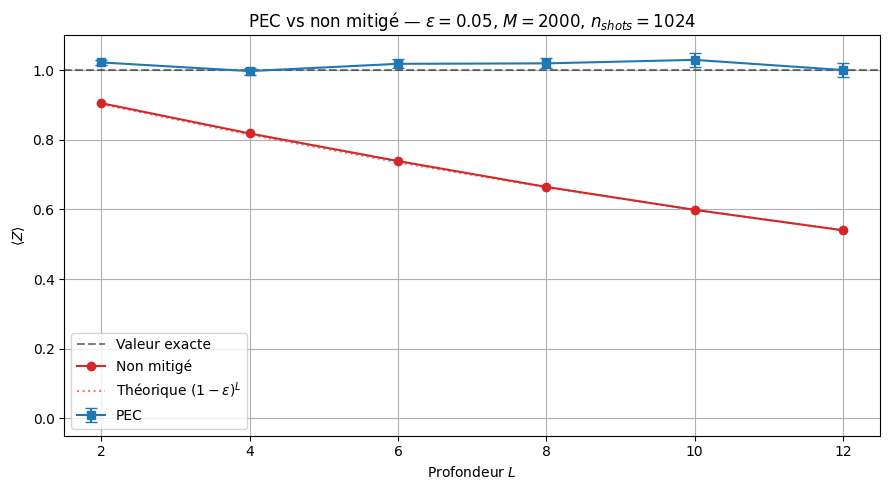

In [112]:
# ============================================================
# Démo B : <Z> vs profondeur L (L pair)
# ============================================================
print("\n=== Démo B : scaling en profondeur (H répété L fois, L pair) ===\n")

eps  = 0.05
qpr  = qpr_depolarizing_analytical(eps)
M    = 2000
n_sh = 1024
Ls   = [2, 4, 6, 8, 10, 12]

results = []
print(f"{'L':<5}{'exact':<10}{'unmit':<12}{'(1-eps)^L':<14}"
      f"{'PEC mean':<14}{'PEC sem':<12}{'gamma^L':<12}")
print("-" * 79)
for L in Ls:
    qc_L = QuantumCircuit(1)
    for _ in range(L):
        qc_L.h(0)
    
    z_ex = expval_Z_exact(qc_L)
    z_un = expval_Z_unmitigated(qc_L, eps, n_shots=20000, seed=42)
    r    = pec_estimate(qc_L, qpr, eps, M=M, n_shots=n_sh, rng=rng, seed=42+L)
    
    results.append({
        'L': L, 'exact': z_ex, 'unmit': z_un,
        'pec_mean': r['mean'], 'pec_sem': r['sem'],
        'gamma_L': qpr['gamma']**L,
    })
    print(f"{L:<5}{z_ex:<10.4f}{z_un:<12.4f}{(1-eps)**L:<14.4f}"
          f"{r['mean']:<14.4f}{r['sem']:<12.4f}{qpr['gamma']**L:<12.4f}")

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
Ls_arr = np.array([r['L'] for r in results])
ax.axhline(1.0, color='k', ls='--', alpha=0.5, label='Valeur exacte')
ax.plot(Ls_arr, [r['unmit'] for r in results], 'o-', label='Non mitigé', color='C3')
ax.plot(Ls_arr, (1 - eps)**Ls_arr, ':', color='C3', alpha=0.6,
        label=r'Théorique $(1-\epsilon)^L$')
ax.errorbar(Ls_arr, [r['pec_mean'] for r in results],
            yerr=[r['pec_sem'] for r in results],
            fmt='s-', label='PEC', color='C0', capsize=4)
ax.set_xlabel('Profondeur $L$')
ax.set_ylabel(r'$\langle Z \rangle$')
ax.set_title(rf'PEC vs non mitigé — $\epsilon={eps}$, $M={M}$, $n_{{shots}}={n_sh}$')
ax.legend()
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.show()


=== Démo C : variance vs profondeur ===

L    std(samples)      gamma^L       ratio     
-----------------------------------------------
2    0.2884            1.1641        0.2477    
4    0.4892            1.3552        0.3610    
6    0.6089            1.5776        0.3859    
8    0.6643            1.8365        0.3617    
10   0.7844            2.1380        0.3669    
12   0.8915            2.4889        0.3582    
16   1.0956            3.3729        0.3248    
20   1.3225            4.5709        0.2893    


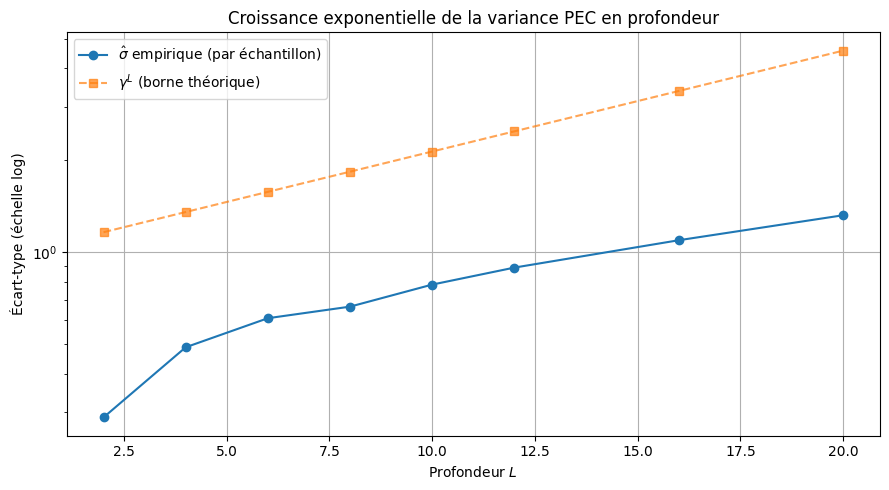

In [113]:
# ============================================================
# Démo C : variance de l'estimateur PEC vs L
# ============================================================
print("\n=== Démo C : variance vs profondeur ===\n")

eps  = 0.05
qpr  = qpr_depolarizing_analytical(eps)
M    = 3000
n_sh = 1024
Ls   = [2, 4, 6, 8, 10, 12, 16, 20]

stds = []
gamma_L = []
for L in Ls:
    qc_L = QuantumCircuit(1)
    for _ in range(L):
        qc_L.h(0)
    r = pec_estimate(qc_L, qpr, eps, M=M, n_shots=n_sh, rng=rng, seed=100+L)
    # Écart-type des échantillons individuels (pas la SEM)
    stds.append(r['samples'].std(ddof=1))
    gamma_L.append(qpr['gamma']**L)

stds = np.array(stds)
gamma_L = np.array(gamma_L)

print(f"{'L':<5}{'std(samples)':<18}{'gamma^L':<14}{'ratio':<10}")
print("-" * 47)
for L, s, g in zip(Ls, stds, gamma_L):
    print(f"{L:<5}{s:<18.4f}{g:<14.4f}{s/g:<10.4f}")

# Plot log-lin
fig, ax = plt.subplots(figsize=(9, 5))
ax.semilogy(Ls, stds, 'o-', label=r'$\hat{\sigma}$ empirique (par échantillon)')
ax.semilogy(Ls, gamma_L, 's--', label=r'$\gamma^L$ (borne théorique)', alpha=0.7)
ax.set_xlabel('Profondeur $L$')
ax.set_ylabel('Écart-type (échelle log)')
ax.set_title('Croissance exponentielle de la variance PEC en profondeur')
ax.legend()
plt.tight_layout()
plt.show()


=== Démo D : convergence en M (L=6 fixé) ===

Estimateur final (M=50000) : 0.986646 ± 0.0026
Cible exacte                : 1.000000


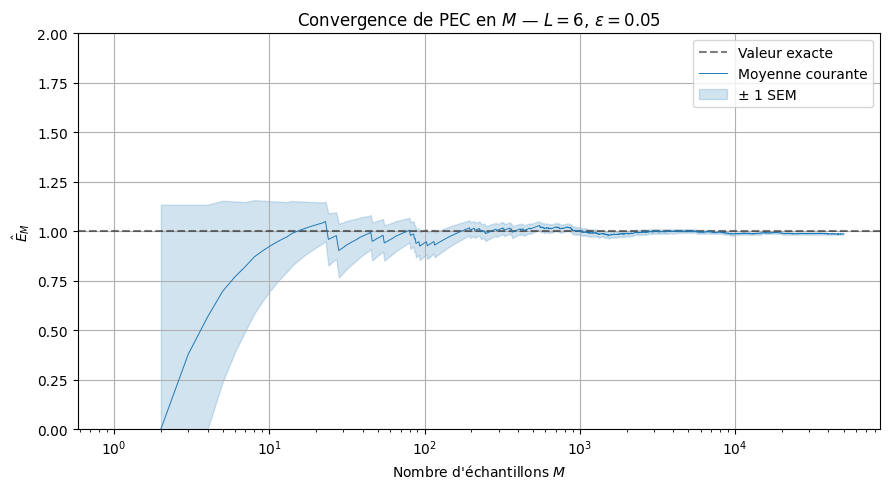

In [116]:
# ============================================================
# Démo D : convergence de PEC en fonction de M
# ============================================================
print("\n=== Démo D : convergence en M (L=6 fixé) ===\n")

eps  = 0.05
qpr  = qpr_depolarizing_analytical(eps)
n_sh = 1024
L    = 6

qc_L = QuantumCircuit(1)
for _ in range(L):
    qc_L.h(0)

# On lance UNE grosse simulation puis on regarde la convergence cumulative
M_max = 50000
r_full = pec_estimate(qc_L, qpr, eps, M=M_max, n_shots=n_sh, rng=rng, seed=2025)

samples = r_full['samples']
running_mean = np.cumsum(samples) / np.arange(1, M_max + 1)
running_sem  = np.array([
    samples[:m].std(ddof=1) / np.sqrt(m) if m > 1 else np.nan
    for m in range(1, M_max + 1)
])

print(f"Estimateur final (M={M_max}) : {r_full['mean']:.6f} ± {r_full['sem']:.4f}")
print(f"Cible exacte                : {expval_Z_exact(qc_L):.6f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.axhline(1.0, color='k', ls='--', alpha=0.5, label='Valeur exacte')
ax.plot(np.arange(1, M_max + 1), running_mean, color='C0', lw=0.7,
        label='Moyenne courante')
ax.fill_between(np.arange(1, M_max + 1),
                running_mean - running_sem, running_mean + running_sem,
                color='C0', alpha=0.2, label='± 1 SEM')
ax.set_xscale('log')
ax.set_xlabel('Nombre d\'échantillons $M$')
ax.set_ylabel(r'$\hat{E}_M$')
ax.set_title(rf'Convergence de PEC en $M$ — $L={L}$, $\epsilon={eps}$')
ax.legend()
ax.set_ylim(0, 2)
plt.tight_layout()
plt.show()